In [1]:
from __future__ import annotations

import anndata
import pandas as pd
import scanpy as sc
from matplotlib import pyplot as plt

In [2]:
# note that this collection of batches is already intersected on the genes
anndata = sc.read(
    "data/pancreas.h5ad",
    backup_url="https://www.dropbox.com/s/qj1jlm9w10wmt0u/pancreas.h5ad?dl=1",
)
anndata

/anaconda3/envs/bibola/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/anaconda3/envs/bibola/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


AnnData object with n_obs × n_vars = 14693 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [3]:
counts = anndata.obs["celltype"].value_counts()
counts.to_frame()

,count
celltype,
alpha,4214
beta,3354
ductal,1804
acinar,1368
not applicable,1154
delta,917
gamma,571
endothelial,289
activated_stellate,284


In [4]:
minority_classes = counts.index[-5:].tolist()  # get the minority classes
# actually subset
anndata = anndata[~anndata.obs["celltype"].isin(minority_classes)].copy()
# reorder according to abundance
anndata.obs["celltype"] = anndata.obs["celltype"].cat.reorder_categories(counts.index[:-5].tolist())
anndata.obs

,celltype,sample,n_genes,batch,n_counts,louvain
index,,,,,,
human1_lib1.final_cell_0001-0,acinar,Baron,3526,0,2.241100e+04,2
human1_lib1.final_cell_0002-0,acinar,Baron,4201,0,2.794900e+04,2
human1_lib1.final_cell_0003-0,acinar,Baron,2119,0,1.689200e+04,2
human1_lib1.final_cell_0004-0,acinar,Baron,2956,0,1.929900e+04,2
human1_lib1.final_cell_0005-0,acinar,Baron,2715,0,1.506700e+04,2
...,...,...,...,...,...,...
reads.29499-3,ductal,Wang,19950,3,1.056558e+06,10
reads.29500-3,ductal,Wang,19950,3,9.926309e+05,10
reads.29501-3,beta,Wang,19950,3,1.751338e+06,10


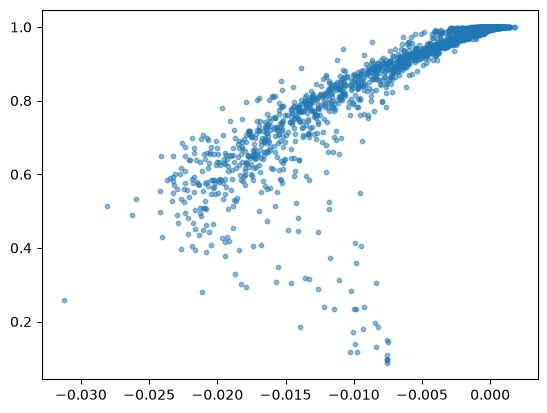

In [5]:
plt.scatter(
    anndata.X.mean(axis=0),
    anndata.X.std(axis=0),
    alpha=.5, s=10
)
plt.show()

In [6]:
sc.pp.pca(anndata)
sc.pp.neighbors(anndata)
sc.tl.umap(anndata)

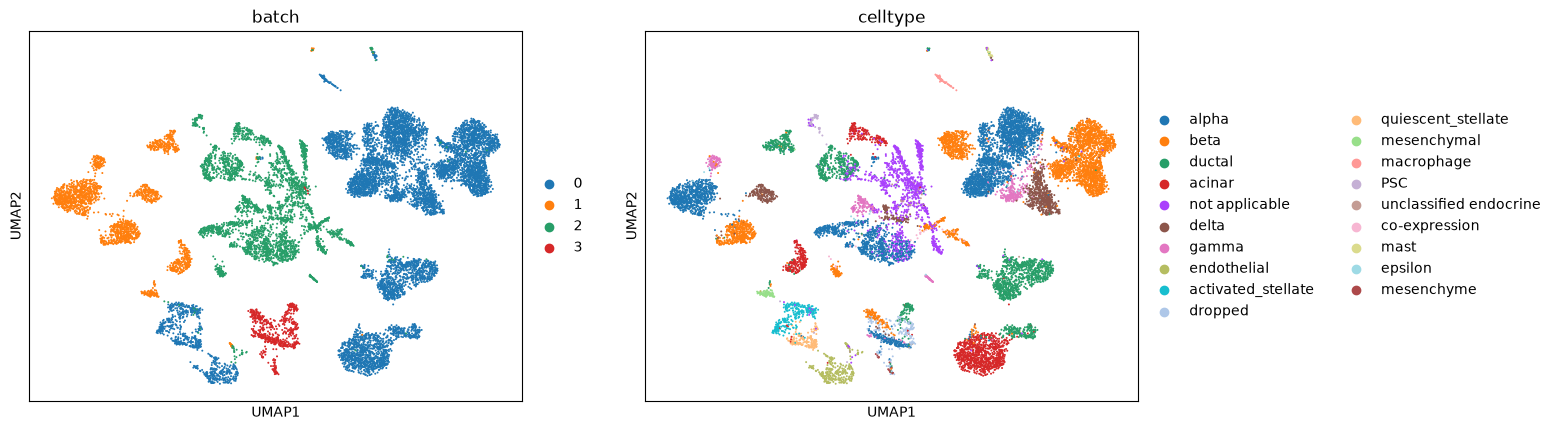

In [7]:
# original UMAP (without batch correction)
sc.pl.umap(anndata, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)

In [8]:
import torch

from bibola.model import ChunkIntegration

In [10]:
batch_correction_model = ChunkIntegration(
    in_channels=anndata.obsm["X_pca"].shape[1],
    hidden_channels=[128,],
    out_channels=50,
    dropout=0.1,
    optimizer_kwargs={"lr": 1e-3}
)
batch_correction_model

ChunkIntegration(in_channels=50, hidden_channels=[128], out_channels=50, optimizer=Adam, not fitted)

In [11]:
batch_correction_model.fit(
    anndata.obsm["X_pca"], anndata.obs["batch"], epochs=5,
    print_every=1, k_inter=5, k_intra=100, norm=1,
    loss_weights={"abs_lisa_loss":1., "topology_loss":1., "knn_loss":1., "reconstruction_loss":1.},
    n_chunks=5
)

Epoch 1/5 - total_loss=-0.0436 (abs_lisa_loss=0.0322, topology_loss=-0.9057, knn_loss=-0.3141, reconstruction_loss=1.0134)
Epoch 2/5 - total_loss=-0.0936 (abs_lisa_loss=0.0233, topology_loss=-0.9136, knn_loss=-0.4394, reconstruction_loss=0.9554)
Epoch 3/5 - total_loss=-0.1280 (abs_lisa_loss=0.0188, topology_loss=-0.9066, knn_loss=-0.5379, reconstruction_loss=0.9139)
Epoch 4/5 - total_loss=-0.1503 (abs_lisa_loss=0.0162, topology_loss=-0.8961, knn_loss=-0.6018, reconstruction_loss=0.8806)
Epoch 5/5 - total_loss=-0.1685 (abs_lisa_loss=0.0140, topology_loss=-0.8839, knn_loss=-0.6548, reconstruction_loss=0.8507)


In [12]:
batch_correction_model.loss_history

loss                                              loss_weights  \
  abs_lisa_loss topology_loss  knn_loss reconstruction_loss abs_lisa_loss   
0      0.032187     -0.905737 -0.314100            1.013405           1.0   
1      0.023252     -0.913632 -0.439403            0.955382           1.0   
2      0.018756     -0.906590 -0.537934            0.913949           1.0   
3      0.016179     -0.896139 -0.601750            0.880607           1.0   
4      0.013960     -0.883869 -0.654754            0.850736           1.0   

                                              
  topology_loss knn_loss reconstruction_loss  
0           1.0      1.0                 1.0  
1           1.0      1.0                 1.0  
2           1.0      1.0                 1.0  
3           1.0      1.0                 1.0  
4           1.0      1.0                 1.0

In [13]:
anndata.obsm["X_corrected"] = batch_correction_model.transform(
    anndata.obsm["X_pca"], anndata.obs["batch"]
).numpy()

from sklearn.decomposition import PCA

# we apply PCA to reduce the collinearity after the batch correction.
pca_model = PCA(n_components=50)
anndata.obsm["X_corrected"] = pca_model.fit_transform(anndata.obsm["X_corrected"])
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors'
    obsm: 'X_pca', 'X_umap', 'X_corrected'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [14]:
sc.pp.neighbors(anndata, use_rep="X_corrected", key_added="neighbors_corrected")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected", key_added="umap_corrected")
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities'

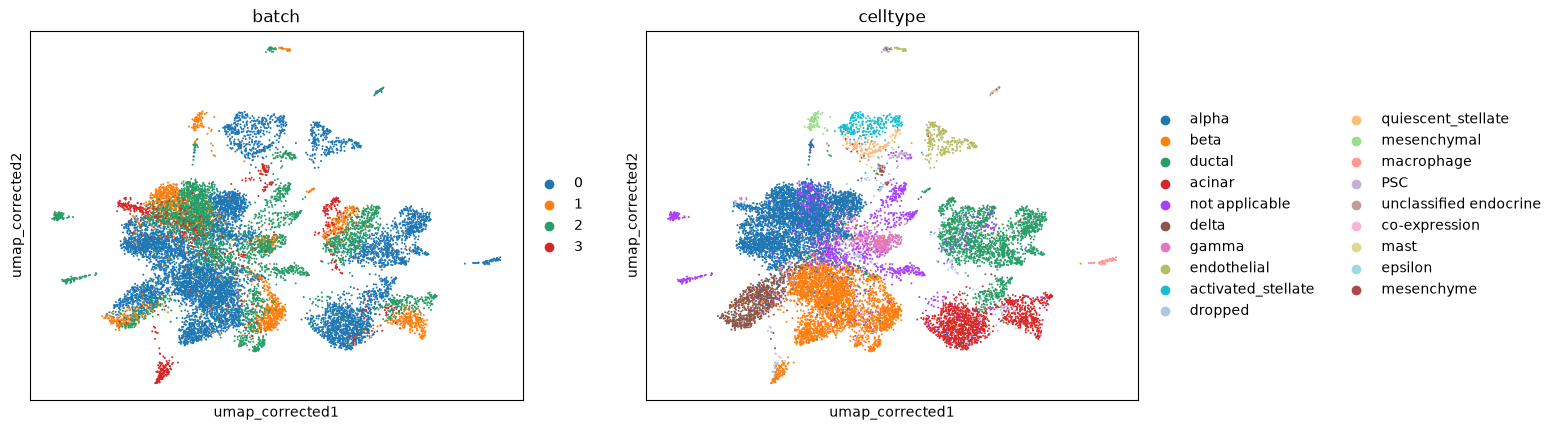

In [15]:
sc.pl.embedding(anndata, basis="umap_corrected", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola

In [16]:
from harmonypy import run_harmony

In [17]:
anndata.obsm["X_pca_harmony"] = run_harmony(anndata.obsm["X_pca"], anndata.obs, "batch").Z_corr
anndata.obsm["X_pca_harmony"]

2026-08-13 18:01:33,178 - harmonypy - INFO - Running Harmony
2026-08-13 18:01:33,179 - harmonypy - INFO -   Parameters:
2026-08-13 18:01:33,179 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-13 18:01:33,179 - harmonypy - INFO -     max_iter_kmeans: 4
2026-08-13 18:01:33,180 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-08-13 18:01:33,180 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-08-13 18:01:33,181 - harmonypy - INFO -     nclust: 100
2026-08-13 18:01:33,181 - harmonypy - INFO -     block_size: 0.05
2026-08-13 18:01:33,182 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-08-13 18:01:33,182 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-08-13 18:01:33,183 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-13 18:01:33,183 - harmonypy - INFO -     verbose: True
2026-08-13 18:01:33,184 - harmonypy - INFO -     random_state: 0
2026-08-13 18:01:33,184 - harmonypy - INFO -   Data: 50 PCs × 14662 cells
2026-08-13 18:01:33,185 - harmonypy - INFO -

array([[  0.15425171,  -4.53972244,  -8.52065468, ...,  -0.38841876,
         -1.45698595,   0.08615991],
       [  3.89552402,  -4.51804066, -10.26223946, ...,  -1.12404025,
          0.90807426,   0.02703966],
       [ -3.71449828,  -4.54087257,  -6.43288279, ...,  -0.76113915,
          0.75945079,   0.08842079],
       ...,
       [  2.96661663,  10.92668152,   5.37792253, ...,   4.19615793,
          1.68354046,   0.28366753],
       [ 14.31705666,  -1.82588816, -12.1900053 , ...,   1.48150325,
          0.90651804,   1.02317023],
       [  3.00160837,  12.04156685,   4.41478348, ...,   0.0424562 ,
          0.6069088 ,   1.26845121]], shape=(14662, 50))

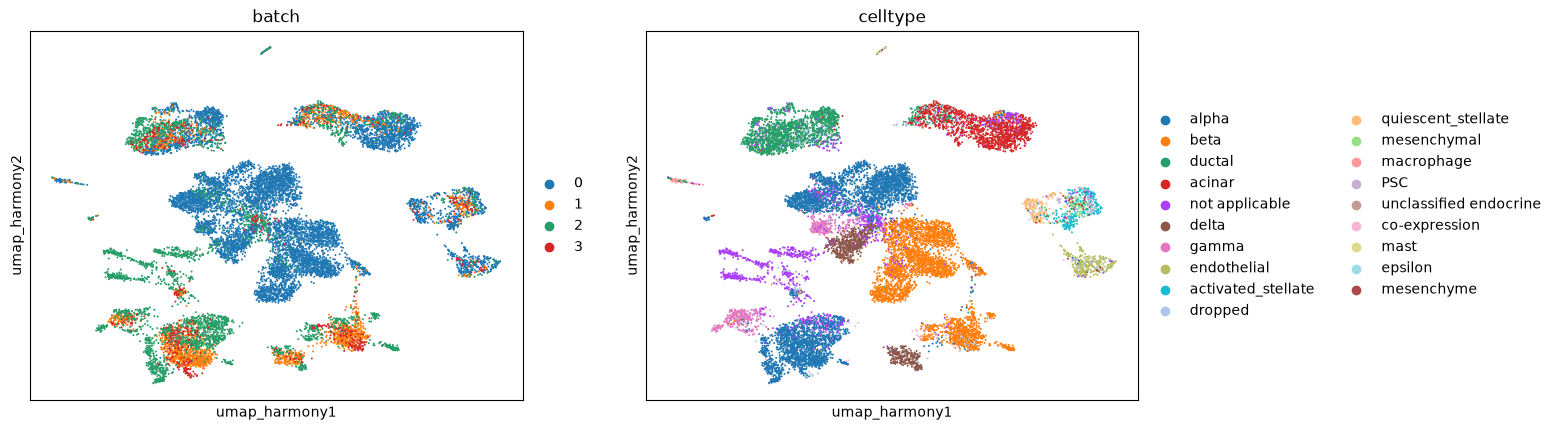

In [18]:
sc.pp.neighbors(anndata, use_rep="X_pca_harmony", key_added="neighbors_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_harmony", key_added="umap_harmony")
sc.pl.embedding(anndata, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy, basis="umap_harmony")
# UMAP after batch correction via harmony

In [18]:
# We can even consider to run the bibola workflow starting from harmony correction, instead of PCA.
# This in order to have a warmer initializzation of the gradient, since the data is already well integrated and we just need to refine the integration at a local level..
# In this case, we will prioritize the spatial autocorrelation (LIBSA) loss since the batches are already "close" enough.

In [26]:
batch_correction_model = ChunkIntegration(
    in_channels=anndata.obsm["X_pca_harmony"].shape[1],
    hidden_channels=[128,],
    out_channels=50,
    dropout=0.1,
    optimizer_kwargs={"lr": 1e-3}
)
batch_correction_model

ChunkIntegration(in_channels=50, hidden_channels=[128], out_channels=50, optimizer=Adam, not fitted)

In [27]:
batch_correction_model.fit(
    anndata.obsm["X_pca_harmony"], anndata.obs["batch"], epochs=5,
    print_every=1, k_inter=5, k_intra=100, norm=1,
    loss_weights={"abs_lisa_loss":.25, "topology_loss": .75, "knn_loss": 2., "reconstruction_loss":1.},
    n_chunks=5
)

Epoch 1/5 - total_loss=-0.0660 (abs_lisa_loss=0.0293, topology_loss=-0.8757, knn_loss=-0.3264, reconstruction_loss=1.0383)
Epoch 2/5 - total_loss=-0.1358 (abs_lisa_loss=0.0254, topology_loss=-0.8842, knn_loss=-0.4314, reconstruction_loss=0.9763)
Epoch 3/5 - total_loss=-0.1881 (abs_lisa_loss=0.0225, topology_loss=-0.8775, knn_loss=-0.5154, reconstruction_loss=0.9309)
Epoch 4/5 - total_loss=-0.2317 (abs_lisa_loss=0.0193, topology_loss=-0.8617, knn_loss=-0.5910, reconstruction_loss=0.8967)
Epoch 5/5 - total_loss=-0.2624 (abs_lisa_loss=0.0171, topology_loss=-0.8469, knn_loss=-0.6433, reconstruction_loss=0.8680)


In [28]:
batch_correction_model.loss_history

loss                                              loss_weights  \
  abs_lisa_loss topology_loss  knn_loss reconstruction_loss abs_lisa_loss   
0      0.029306     -0.875661 -0.326425            1.038308          0.25   
1      0.025405     -0.884188 -0.431440            0.976309          0.25   
2      0.022539     -0.877465 -0.515450            0.930902          0.25   
3      0.019312     -0.861717 -0.590969            0.896687          0.25   
4      0.017105     -0.846885 -0.643320            0.867984          0.25   

                                              
  topology_loss knn_loss reconstruction_loss  
0          0.75      2.0                 1.0  
1          0.75      2.0                 1.0  
2          0.75      2.0                 1.0  
3          0.75      2.0                 1.0  
4          0.75      2.0                 1.0

In [29]:
anndata.obsm["X_corrected_after_harmony"] = batch_correction_model.transform(
    anndata.obsm["X_pca_harmony"], anndata.obs["batch"]
).numpy()

from sklearn.decomposition import PCA

pca_model = PCA(n_components=50)
anndata.obsm["X_corrected_after_harmony"] = pca_model.fit_transform(anndata.obsm["X_corrected_after_harmony"])
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony', 'neighbors_corrected_after_harmony', 'umap_corrected_after_harmony'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony', 'umap_corrected_after_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities', 'neighbors_corrected_after_harmony_distances', 'neighbors_corrected_after_harmony_connectivities'

In [30]:
sc.pp.neighbors(anndata, use_rep="X_corrected_after_harmony", key_added="neighbors_corrected_after_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected_after_harmony", key_added="umap_corrected_after_harmony")
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony', 'neighbors_corrected_after_harmony', 'umap_corrected_after_harmony'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony', 'umap_corrected_after_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities', 'neighbors_corrected_after_harmony_distances', 'neighbors_corrected_after_harmony_connectivities'

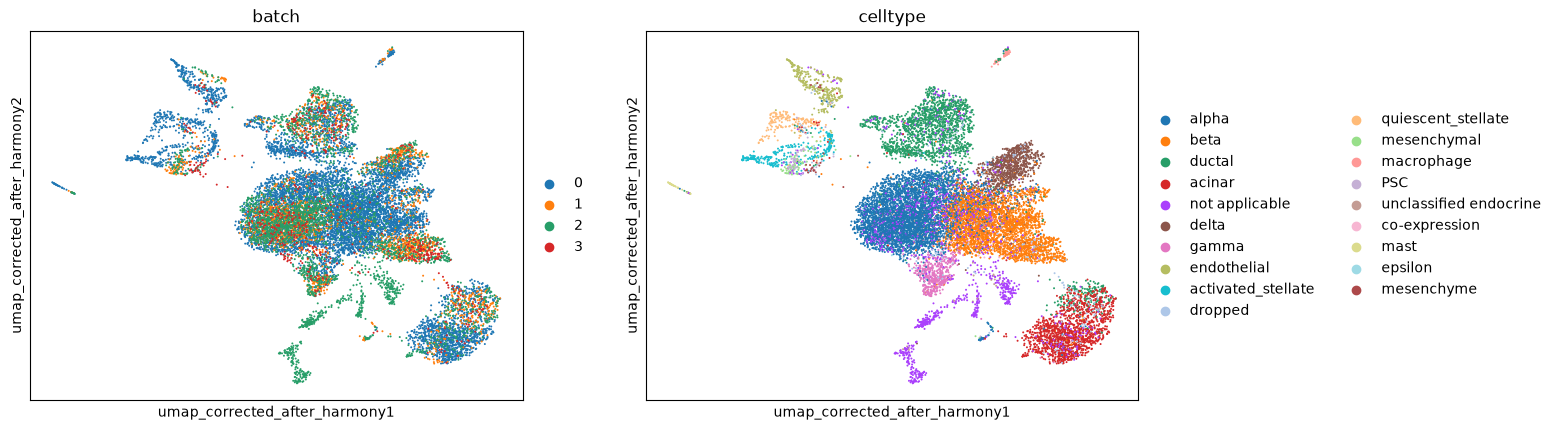

In [31]:
sc.pl.embedding(anndata, basis="umap_corrected_after_harmony", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola, starting from harmony
# we see an improvement in the integration of the batches, and a better separation of the cell types, compared to harmony alone.